In [4]:
import tabula
import pandas as pd

# Path to your document
file_path = r"G:\My Drive\00) Interview Prep\00) Companies\EFG\Round 3 Slides\stream_2762463_427c397b-57d2-4955-962e-8389c43556e1_doc1.pdf"

# Read all tables from all pages
# 'pages="all"' ensures the entire 65+ page document is processed
tables = tabula.read_pdf(file_path, pages='all', multiple_tables=True)

# Combine all extracted tables into a single DataFrame
df = pd.concat(tables, ignore_index=True)

# Save to CSV or Excel
df.to_csv("ownership_data.csv", index=False)

import os

# Create the folder if it doesn't exist
if not os.path.exists('images'):
    os.makedirs('images')

In [2]:
def simple_extract(file_path):
    print("Starting extraction... this may take a minute for 65+ pages.")
    
    tables = tabula.read_pdf(file_path, pages='all')
    
    if not tables:
        print("Error: Tabula could not find any tables.")
        return None

    # Merge all pages into one DataFrame
    df = pd.concat(tables, ignore_index=True)

    # Cleanup: Strip any weird whitespace from column names
    df.columns = [str(c).strip() for c in df.columns]

    # Numeric Cleaning: Convert columns to numbers safely
    # This handles the dots (thousands) and commas (decimals)
    numeric_cols = ['HOLDINGS_SCRIPLESS', 'HOLDINGS_SCRIP', 'TOTAL_HOLDING_SHARES', 'PERCENTAGE']
    
    for col in numeric_cols:
        if col in df.columns:
            # We convert to string, remove dots, change commas to dots, then force to numeric
            df[col] = (
                df[col].astype(str)
                .str.replace('.', '', regex=False)
                .str.replace(',', '.', regex=False)
            )
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

# --- RUN IT ---
file_path = r"G:\My Drive\00) Interview Prep\00) Companies\EFG\Round 3 Slides\stream_2762463_427c397b-57d2-4955-962e-8389c43556e1_doc1.pdf"
df = simple_extract(file_path)

if df is not None:
    # Remove rows where the main data is missing (handles footer/header noise)
    df = df.dropna(subset=[df.columns[0]]) 
    
    df.to_csv("cleaned_ownership_data.csv", index=False)
    print(f"Success! {len(df)} rows saved to cleaned_ownership_data.csv")
    print("\nColumn names found in your PDF:")
    print(df.columns.tolist())

Starting extraction... this may take a minute for 65+ pages.
Success! 7257 rows saved to cleaned_ownership_data.csv

Column names found in your PDF:
['DATE', 'SHARE_CODE', 'ISSUER_NAME', 'INVESTOR_NAME', 'INVESTOR_TYPE', 'LOCAL_FOREIGN', 'NATIONALITY', 'DOMICILE', 'HOLDINGS_SCRIPLESS', 'HOLDINGS_SCRIP', 'TOTAL_HOLDING_SHARES', 'PERCENTAGE']


C:\Users\Admin\AppData\Local\Temp\ipykernel_41844\155846909.py:19: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.scatter_geo(


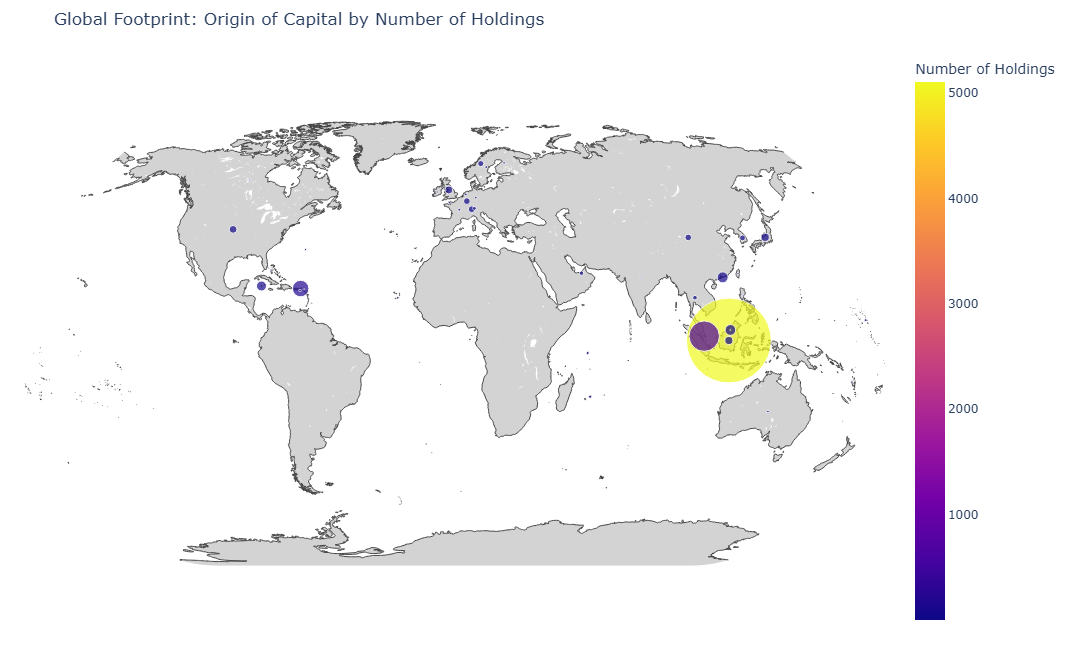

FileNotFoundError: [Errno 2] No such file or directory: 'images\\global_map.png'

In [3]:
import plotly.express as px
import pandas as pd

def analyze_ownership_bubble_map(df):
    df['DOMICILE_CLEAN'] = df['DOMICILE'].fillna('UNKNOWN').astype(str).str.upper().str.strip()
    
    # Count holdings (including Indonesia this time for scale)
    country_counts = df['DOMICILE_CLEAN'].value_counts().reset_index()
    country_counts.columns = ['Country', 'Number of Holdings']
    
    # Fix Plotly mapping for financial havens
    country_counts['Country'] = country_counts['Country'].replace({
        'VIRGIN ISLANDS, BRITISH': 'British Virgin Islands',
        'UNITED STATES': 'United States',
        'UNKNOWN': 'Unknown' # Plotly will ignore this, which is fine for the map
    })

    # Use a Bubble Map instead of Choropleth
    fig = px.scatter_geo(
        country_counts,
        locations="Country",
        locationmode="country names",
        size="Number of Holdings", # The size of the bubble dictates the volume
        color="Number of Holdings",
        hover_name="Country",
        projection="natural earth",
        title="Global Footprint: Origin of Capital by Number of Holdings",
        size_max=60, # Caps the maximum size so Indonesia doesn't cover all of Asia
        color_continuous_scale=px.colors.sequential.Plasma
    )
    
    fig.update_layout(
        geo=dict(showframe=False, showcoastlines=True, landcolor='lightgray', resolution=50),
        width=1000, 
        height=650, 
        margin=dict(l=20, r=20, t=50, b=20)
    )
    fig.show()

    fig.write_image("images/global_map.png")

analyze_ownership_bubble_map(df)

In [ ]:
import pandas as pd
import plotly.graph_objects as go

def analyze_whale_discrepancy(df):
    # --- 1. CLEANING & CLASSIFICATION ---
    df['TOTAL_HOLDING_SHARES'] = (
        df['TOTAL_HOLDING_SHARES']
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
    df['TOTAL_HOLDING_SHARES'] = pd.to_numeric(df['TOTAL_HOLDING_SHARES'], errors='coerce')
    df['DOMICILE_CLEAN'] = df['DOMICILE'].fillna('UNKNOWN').astype(str).str.upper().str.strip()

    df['GEO_CLASSIFICATION'] = df['DOMICILE_CLEAN'].apply(
        lambda x: 'Domestic (Indonesia)' if 'INDONESIA' in x else 'Foreign'
    )

    # --- 2. CALCULATE PROPORTIONS ---
    # Percentage of Total Positions (Count)
    count_prop = df['GEO_CLASSIFICATION'].value_counts(normalize=True) * 100
    
    # Percentage of Total Share Volume
    vol_sum = df.groupby('GEO_CLASSIFICATION')['TOTAL_HOLDING_SHARES'].sum()
    vol_prop = (vol_sum / vol_sum.sum()) * 100

    # Ensure indexes align for plotting
    categories = ['Domestic (Indonesia)', 'Foreign']
    
    counts = [count_prop.get(cat, 0) for cat in categories]
    volumes = [vol_prop.get(cat, 0) for cat in categories]

    # --- 3. PLOT GROUPED BAR CHART ---
    fig = go.Figure(data=[
        go.Bar(
            name='% of Total Positions (Headcount)', 
            x=categories, 
            y=counts,
            text=[f"{val:.1f}%" for val in counts],
            textposition='auto',
            marker_color='#3A5FCD'  # Royal Blue
        ),
        go.Bar(
            name='% of Total Share Volume (Wealth)', 
            x=categories, 
            y=volumes,
            text=[f"{val:.1f}%" for val in volumes],
            textposition='auto',
            marker_color='#FF8C00'  # Dark Orange
        )
    ])

    # Customize layout to make the insight pop
    fig.update_layout(
        title='The Foreign Whale Effect: Investor Headcount vs. Actual Volume Controlled',
        barmode='group',
        xaxis_title='Investor Domicile',
        yaxis_title='Percentage (%)',
        yaxis=dict(range=[0, 100]), # Standardize y-axis to 100%
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        ),
        template='plotly_white'
    )
    
    fig.show()

    fig.write_image("images/whale_effect.png")

# Run the updated visualization
df = pd.read_csv("cleaned_ownership_data.csv")
analyze_whale_discrepancy(df)

In [ ]:
import plotly.express as px
import pandas as pd

def analyze_scrip_reality(df):
    # Clean the numeric data
    df['HOLDINGS_SCRIP'] = df['HOLDINGS_SCRIP'].fillna(0).astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    df['HOLDINGS_SCRIP'] = pd.to_numeric(df['HOLDINGS_SCRIP'], errors='coerce')
    
    df['TOTAL_HOLDING_SHARES'] = df['TOTAL_HOLDING_SHARES'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    df['TOTAL_HOLDING_SHARES'] = pd.to_numeric(df['TOTAL_HOLDING_SHARES'], errors='coerce')

    # Aggregate by company
    issuer_scrip = df.groupby(['SHARE_CODE', 'ISSUER_NAME']).agg(
        TOTAL_SCRIP=('HOLDINGS_SCRIP', 'sum'),
        TOTAL_SHARES=('TOTAL_HOLDING_SHARES', 'sum') 
    ).reset_index()
    
    # Calculate True Ratio
    issuer_scrip['SCRIP_PERCENTAGE'] = (issuer_scrip['TOTAL_SCRIP'] / issuer_scrip['TOTAL_SHARES']) * 100
    issuer_scrip['SCRIP_PERCENTAGE'] = issuer_scrip['SCRIP_PERCENTAGE'].fillna(0)
    
    # Filter out fully modernized companies (0% scrip)
    legacy_companies = issuer_scrip[issuer_scrip['SCRIP_PERCENTAGE'] > 0]
    
    fig = px.scatter(
        legacy_companies,
        x='TOTAL_SHARES',
        y='SCRIP_PERCENTAGE',
        hover_name='ISSUER_NAME',
        hover_data=['SHARE_CODE', 'TOTAL_SCRIP'],
        log_x=True, # Applies a logarithmic scale to account for arbitrary share splits
        title="The Scrip Reality: Proportion of Physical Shares vs. Scale of Holdings",
        labels={
            'TOTAL_SHARES': 'Total Block Shares Issued (Log Scale)',
            'SCRIP_PERCENTAGE': 'Physical Scrip Percentage (%)'
        },
        color='SCRIP_PERCENTAGE',
        color_continuous_scale='Reds'
    )
    
    # Add styling
    fig.update_traces(marker=dict(size=10, opacity=0.7, line=dict(width=1, color='DarkRed')))
    fig.show()

    fig.write_image("images/scrip_reality.png")

analyze_scrip_reality(df)

In [ ]:
import plotly.express as px
import pandas as pd

def analyze_whale_fragmentation(df):
    # Group by issuer to find total concentration AND the count of >1% investors
    fragmentation = df.groupby(['SHARE_CODE', 'ISSUER_NAME']).agg(
        TOTAL_BLOCK_OWNERSHIP=('PERCENTAGE', 'sum'),
        INVESTOR_COUNT=('INVESTOR_NAME', 'count') # How many entities make up that block?
    ).reset_index()
    
    # Cap total ownership at 100% just in case of data rounding errors
    fragmentation['TOTAL_BLOCK_OWNERSHIP'] = fragmentation['TOTAL_BLOCK_OWNERSHIP'].clip(upper=100)
    
    fig = px.scatter(
        fragmentation, 
        x='INVESTOR_COUNT', 
        y='TOTAL_BLOCK_OWNERSHIP', 
        hover_name='ISSUER_NAME',
        hover_data=['SHARE_CODE'],
        title='Ownership Structure: Single Whale vs. Fragmented Funds',
        labels={
            'TOTAL_BLOCK_OWNERSHIP': 'Total Block Ownership (%)', 
            'INVESTOR_COUNT': 'Number of >1% Investors'
        },
        color='TOTAL_BLOCK_OWNERSHIP',
        color_continuous_scale=px.colors.sequential.Viridis
    )
    
    # Add styling
    fig.update_traces(marker=dict(size=9, opacity=0.7, line=dict(width=1, color='DarkSlateGrey')))
    # Add a horizontal line at 50% for majority control visual threshold
    fig.add_hline(y=50, line_dash="dash", line_color="red", annotation_text="Majority Control Threshold")
    
    fig.show()

    fig.write_image("images/fragmentation.png")

analyze_whale_fragmentation(df)

In [ ]:
from itables import show

def analyze_hidden_whales_datatable(df):
    df['DOMICILE_CLEAN'] = df['DOMICILE'].fillna('UNKNOWN').astype(str).str.upper().str.strip()
    foreign_df = df[~df['DOMICILE_CLEAN'].str.contains('INDONESIA')]
    
    # Expanded list of tycoon/conglomerate keywords
    tycoon_keywords = [
        'SALIM', 'BAKRIE', 'WIDJAJA', 'HARTONO', 'PANGESTU', 'TANOTO', 
        'THOHIR', 'PANIGORO', 'TJIPUTRA', 'RIADY', 'SUTANTO', 'WONOWIDJOJO', 
        'KALLA', 'DJUHARI', 'SUDONO', 'TANOESOEDIBJO', 'PRAYOGO', 
        'SOERYADJAYA', 'LO KHENG HONG', 'KARTONO'
    ]
    pattern = '|'.join(tycoon_keywords)
    
    hidden_whales = foreign_df[foreign_df['INVESTOR_NAME'].str.upper().str.contains(pattern, na=False)]
    
    cols_to_show = ['INVESTOR_NAME', 'SHARE_CODE', 'DOMICILE_CLEAN', 'PERCENTAGE']
    final_df = hidden_whales[cols_to_show].sort_values(by='PERCENTAGE', ascending=False)
    
    # Render the interactive HTML table
    show(
    final_df, 
    classes="display", 
    scrollX=True, 
    paging=True, 
    column_filters="header"
    )

analyze_hidden_whales_datatable(df)

In [ ]:
import pandas as pd
import plotly.express as px

def analyze_shadow_whales(df):
    # --- 1. CLEANING ---
    df['PERCENTAGE'] = pd.to_numeric(
        df['PERCENTAGE'].astype(str).str.replace(',', '.'), errors='coerce'
    )
    df['TOTAL_HOLDING_SHARES'] = pd.to_numeric(
        df['TOTAL_HOLDING_SHARES'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False), errors='coerce'
    )
    
    # --- 2. ISOLATE THE NEWLY REVEALED BRACKET (1% to <5%) ---
    exposed_bracket = df[(df['PERCENTAGE'] >= 1.0) & (df['PERCENTAGE'] < 5.0)].copy()
    
    # Flag the "Shadow Whales" (those hugging the old 5% line, e.g., 4.5% to 4.99%)
    exposed_bracket['IS_SHADOW_WHALE'] = exposed_bracket['PERCENTAGE'] >= 4.5
    
    # --- 3. PLOT THE DISTRIBUTION ---
    fig = px.histogram(
        exposed_bracket,
        x='PERCENTAGE',
        nbins=40, # Creates bins of roughly 0.1% each
        color='IS_SHADOW_WHALE',
        color_discrete_map={True: '#B22222', False: '#708090'}, # Firebrick Red vs Slate Gray
        title='Exposing the "Shadow Whales": Distribution of Newly Revealed 1-4.99% Holdings',
        hover_data=['ISSUER_NAME', 'INVESTOR_NAME', 'TOTAL_HOLDING_SHARES']
    )
    
    # Calculate stats for annotation
    shadow_count = exposed_bracket['IS_SHADOW_WHALE'].sum()
    shadow_volume = exposed_bracket.loc[exposed_bracket['IS_SHADOW_WHALE'], 'TOTAL_HOLDING_SHARES'].sum()
    
    # Make it look good
    fig.update_layout(
        barmode='stack',
        xaxis_title='Ownership Percentage (%)',
        yaxis_title='Number of Investor Positions',
        showlegend=False,
        template='plotly_white'
    )
    
    # Add annotation pointing to the 4.5-4.99% cluster
    fig.add_annotation(
        x=4.8, y=shadow_count + 10,
        text=f"<b>{shadow_count} Shadow Whales</b><br>Caught hugging the<br>old 5% radar",
        showarrow=True, arrowhead=2, arrowcolor="#B22222",
        font=dict(color="#B22222"), ax=-60, ay=-40
    )
    
    fig.show()
    
    # Print summary statistics
    print("--- THE SHADOW WHALE IMPACT ---")
    print(f"Total positions exposed between 1% and 4.99%: {len(exposed_bracket)}")
    print(f"Positions caught specifically between 4.5% and 4.99%: {shadow_count}")
    print(f"Total share volume exposed in the 4.5-4.99% bracket: {shadow_volume:,.0f} shares")

    fig.write_image("images/shadow_whales.png")


# Run the analysis
df = pd.read_csv("cleaned_ownership_data.csv")
analyze_shadow_whales(df)

